In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from firedrake import *
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager, RectangleMesh, ExtrudedMesh, FunctionSpace, Function, SpatialCoordinate, FiniteElement
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

import irksome
from irksome import Dt
from collections import defaultdict, OrderedDict

from matplotlib.gridspec import GridSpec

### Import our homemade functions ###
import scripts.model_modules
from scripts.mesh_generating import *

import string

%matplotlib widget

# 1. Load the necessary data

### 1.1 Borehole locations

In [2]:
### Load boreholes
borehole_locations = pd.read_csv('Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

# Do the meshing

In [3]:
upscale_factor_fine = 1/10
src_bed_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif"
src_surf_fine_path = "Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif"
layer_num=5

In [48]:
mesh_fine = mesh_creator(src_bed_fine_path, src_surf_fine_path, resamp_factor=upscale_factor_fine, layers=layer_num)
mesh_fine.tolerance = 1e-10
x_src, y_src, z_src = SpatialCoordinate(mesh_fine)

pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)

# chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
# chk.load(flow, name="fine_mesh_flow")

chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

enhancement_factor = 1.97

flow.dat.data_wo[0][:] = flow.dat.data_ro[0][:]*enhancement_factor

# new_vel = firedrake.Function(velocity_space)
# new_vel.interpolate(flow.dat.data_ro[0]*1.97)
u,p = firedrake.split(flow)


/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


In [6]:
# enhancement_factor = 1.97
# u = u * enhancement_factor

### 1.4 Load the temperature field

In [49]:
V = firedrake.FunctionSpace(mesh_fine, "CG", 1)

T = firedrake.Function(V)

chk = DumbCheckpoint("Saved_Models/fine_mesh_temperature_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(T, name="fine_mesh_temp")

T_init = T.copy(deepcopy=True)

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


# 2. Make the temperature time stepping

In [108]:
δx = mesh_fine.cell_sizes.dat.data_ro[:].min()
umax = flow.sub(0).dat.data_ro[:].max()
δt = Constant(spy/.1)

In [109]:
from ufl import Measure
dx = ufl.Measure("dx", domain=mesh_fine)


ϕ = firedrake.TestFunction(V)

geo_flux = 0.04 # W/m^2 
k = Constant(2.22)  # W / m C

geothermal_flux = -geo_flux*ϕ  * ds_b
F_diffusion = k*inner(grad(T), grad(ϕ)) * dx
F_advection = - ρ * c * T * inner(u, grad(ϕ)) * dx

F = ρ * c * Dt(T) * ϕ * dx + F_diffusion + F_advection + geothermal_flux

In [110]:
mag = 2

T_mean = Constant(-33) #average temp (C)
T_Mean = -33 #average temp (C)

temperature_expr = T_mean - (z_src - 2000)*.01

surface_temp_bc = firedrake.DirichletBC(V, temperature_expr, 'top')

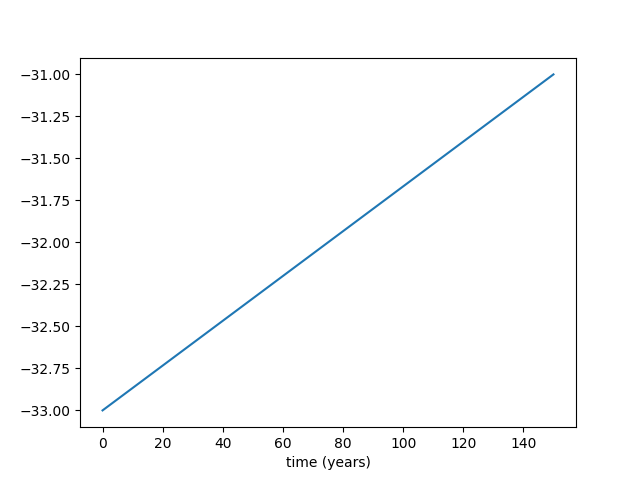

In [111]:
δT = 25.0
θ = 1 * π / 2
year = spy
years = 150
final_time = years * spy # years modeling * spy


freq = 1 # 1 for annual cycle
num_steps = int(final_time / float(δt))

# def surface_temperature(t):
#     return T_Mean + δT * np.sin(2 * π *freq* t / year + θ) + (t/final_time)*1

def surface_temperature(t):
    return T_Mean + (t/final_time)*mag

ts = np.linspace(0.0, final_time, num_steps + 1)

surface_temps = surface_temperature(ts)

fig, ax = plt.subplots()

ax.set_xlabel("time (years)")
#ax.set_ylabel("temperature (${}^\circ$C)")
ax.plot(ts / spy, surface_temps);

In [112]:
# surface_temps = np.array([-30.5 , -30.5, -30.5, -30.9, -31, -31.5 , -31.8, -32, -32.2, -32.4, -32. ])

# fig, ax = plt.subplots()

# ax.set_xlabel("time (years)")
# #ax.set_ylabel("temperature (${}^\circ$C)")
# ax.plot(ts / spy, surface_temps);

In [113]:
method = irksome.BackwardEuler()
temperature_solver = irksome.TimeStepper(F, method, Constant(0.0), δt, T, bcs=surface_temp_bc)

In [114]:
import tqdm
final_time = years* spy 
num_steps = int(final_time / float(δt))
Ts = [T.copy(deepcopy=True)]

for step in tqdm.trange(num_steps):
    t = ts[step]
    T_mean.assign(surface_temperature(t))

    temperature_solver.advance()


    Ts.append(T.copy(deepcopy=True))


100%|██████████| 15/15 [00:27<00:00,  1.87s/it]


# 3. Plot the temperatures

In [115]:
z_vals = mesh_fine.coordinates.dat.data_ro[:,2]
depth_values = np.arange(z_vals.min(), z_vals.max(), 5)

temp_dict_climate = {}
temp_dict_no_climate = {}

for x_bore, y_bore, name_bore in zip(transformed_x, transformed_y, borehole_locations['Core']):
    temp_coords = []
    temp_clim_vals = []
    temp_no_clim_vals = []
    for z_bore in depth_values:
        try:
            temp_clim = Ts[-1].at(x_bore, y_bore, z_bore)
            temp_no_clim = T_init.at(x_bore, y_bore, z_bore)
            temp_coords.append([x_bore, y_bore, z_bore])
            temp_clim_vals.append(temp_clim)
            temp_no_clim_vals.append(temp_no_clim)


        except:
            continue
    if len(temp_clim_vals) > 0:
        temp_dict_climate[name_bore] = [np.array(temp_clim_vals), np.array(temp_coords)]
        temp_dict_no_climate[name_bore] = [np.array(temp_no_clim_vals), np.array(temp_coords)]


In [58]:
avg_temps = pd.read_pickle('Borehole_Temps/avg_temps.pkl')
residual_temps = pd.read_pickle('Borehole_Temps/residual_temps.pkl')

boreholes = ['ALHIC1901', 'ALHIC1902', 'ALHIC1903', 'ALHIC2201', 'ALHIC2301', 'ALHIC2302', 'ALHIC2401']

# for i in avg_temps:
#     print(avg_temps[i][0].values[0])
#     print(i)

core_surface_z = {'ALHIC1901': 1937.88,
                  'ALHIC1902': 1940.76, 
                  'ALHIC1903': 1884.84,
                  'ALHIC2201': 1934.54,
                  'ALHIC2301': 1865.68, 
                  'ALHIC2302': 1940.76, 
                  'ALHIC2401': 1865.68}

<>:47: SyntaxWarning: invalid escape sequence '\c'
<>:47: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1236320/435159723.py:47: SyntaxWarning: invalid escape sequence '\c'
  ax.annotate('model temperature offset: {:.2f}$^\circ$C'.format(model_temp_offset_mean), xy=(0.01, 0.01), xycoords='axes fraction')
/tmp/ipykernel_1236320/435159723.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1236320/435159723.py:121: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


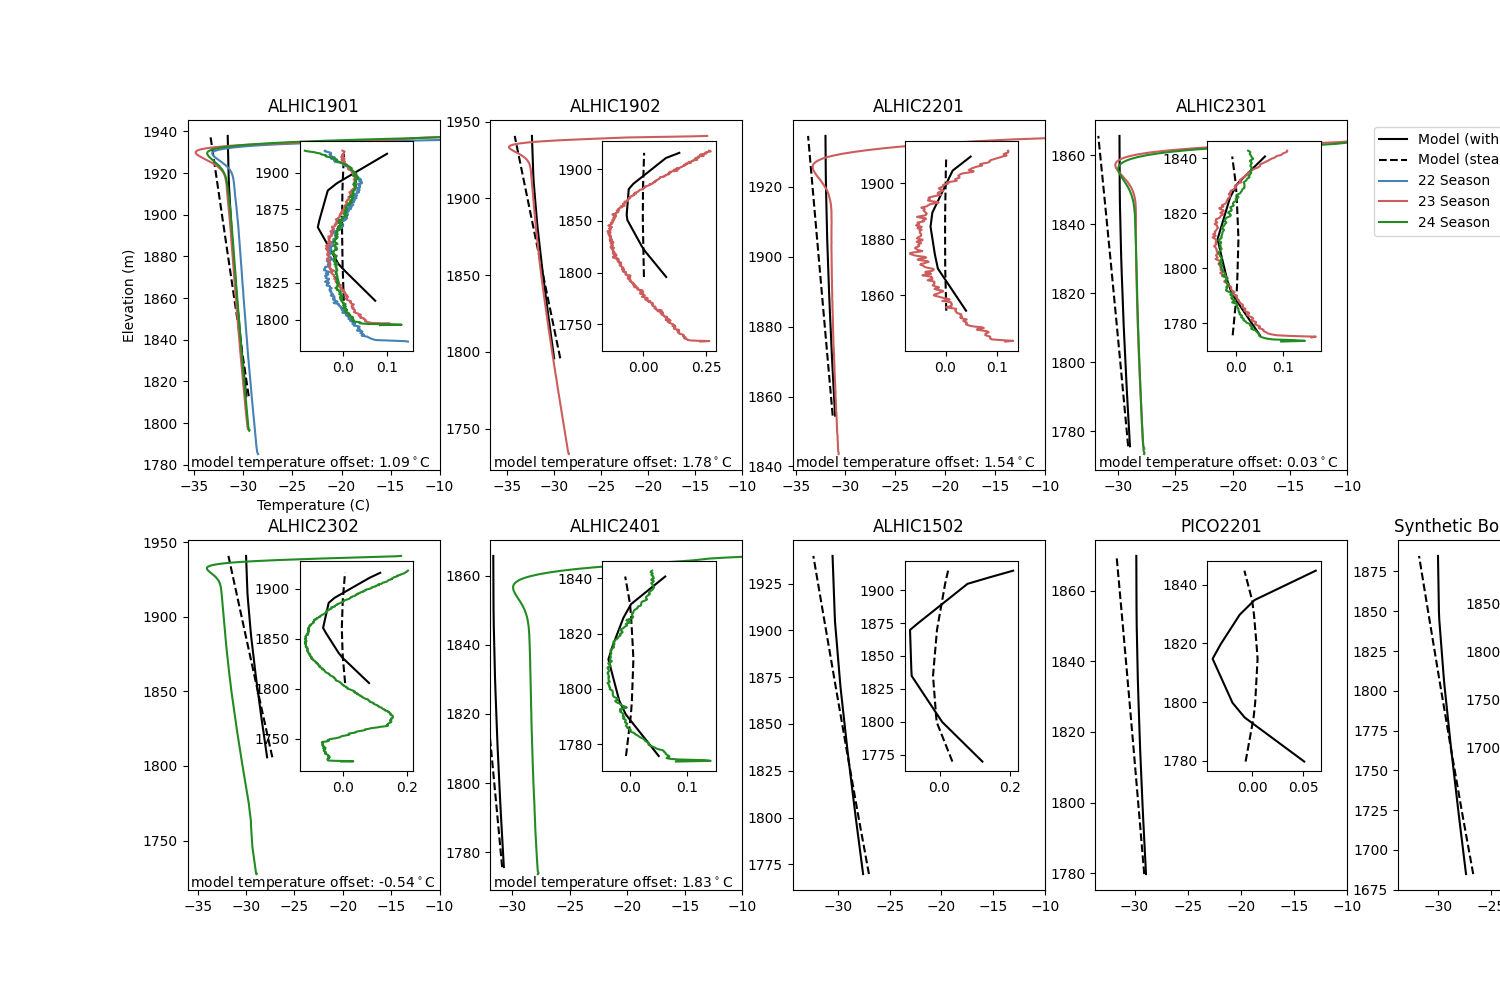

In [116]:
fig,axes = plt.subplots(2, int(((len(temp_dict_climate)+1) /2)+.5), figsize=[15,10])
fig.delaxes(axes[0,-1])

temperature_residuals_with_offset = []
borehole_offset_dict = defaultdict(list)
### Calculate the offset between the model and the observations ###
for name, ax in zip(temp_dict_climate, fig.axes[:-1]):
    for borehole_name_data in avg_temps:
        if borehole_name_data.startswith(name):

            model_zs = temp_dict_climate[name][1][:,2]
            model_temps = temp_dict_climate[name][0]

            z_offset = model_zs[-1] - core_surface_z[name]
            model_zs = model_zs - z_offset


            data_zs = avg_temps[borehole_name_data][0].values
            data_temps = avg_temps[borehole_name_data][2].values



            # print('data z is '+str(data_zs[-1])+' and the model z is '+str(model_zs[0]))
            if data_zs[-1] < model_zs[0]:
                f = scipy.interpolate.interp1d(data_zs, data_temps)
                data_temps_model_zs = f(model_zs)


                mean_temp_offsets = np.mean(model_temps[:-5] - data_temps_model_zs[:-5])
            else:
                print(name)

        borehole_offset_dict[name].append(mean_temp_offsets)
    model_temp_offset_mean = np.mean(borehole_offset_dict[name])

    try:

        z_offset = temp_dict_climate[name][1][:,2][-1] - core_surface_z[name]
        ax.plot(temp_dict_climate[name][0] - model_temp_offset_mean, temp_dict_climate[name][1][:,2] - z_offset, c='black',label='Model (with climate)')
        ax.plot(temp_dict_no_climate[name][0] - model_temp_offset_mean, temp_dict_no_climate[name][1][:,2] - z_offset, c='black', label='Model (steady state)', ls = '--')

        axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
        axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0][:-5]), temp_dict_climate[name][1][:,2][:-5]-z_offset, c='black')
        axinses.plot(scipy.signal.detrend(temp_dict_no_climate[name][0][:-5]), temp_dict_no_climate[name][1][:,2][:-5]-z_offset, ls = '--',c='black')


        ax.annotate('model temperature offset: {:.2f}$^\circ$C'.format(model_temp_offset_mean), xy=(0.01, 0.01), xycoords='axes fraction')
        
    except:
        
        ax.plot(temp_dict_climate[name][0], temp_dict_climate[name][1][:,2], c='black', label='Model')
        ax.plot(temp_dict_no_climate[name][0], temp_dict_no_climate[name][1][:,2], c='black', label='Model (steady state)', ls = '--')

        axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
        axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0][:-5]), temp_dict_climate[name][1][:,2][:-5], c='black')
        axinses.plot(scipy.signal.detrend(temp_dict_no_climate[name][0][:-5]), temp_dict_no_climate[name][1][:,2][:-5], ls = '--',c='black')


        min_temp = temp_dict_no_climate[name][0].min()
        ax.set_xlim([min_temp - 2, -10])

    ax.set_title(name)


    for i in avg_temps:
        if i.startswith(name):
            if i[-2:] == '22':
                color = 'steelblue'
            elif i[-2:] == '23':
                color = 'indianred'
            elif i[-2:] == '24':
                color = 'forestgreen'
            ax.plot(avg_temps[i][2], avg_temps[i][0], label=i[-2:]+' Season',c=color)
            axinses.plot(residual_temps[i][2], residual_temps[i][0], label=i[-2:]+' Season',c=color)

            min_temp = avg_temps[i][2].min()
            ax.set_xlim([min_temp - 2, -10])
    if name == 'ALHIC1901':
        leg = ax.legend( loc = 'upper right')

fig.axes[0].set_ylabel('Elevation (m)')
fig.axes[0].set_xlabel('Temperature (C)')



### Plot the synthetic borehole temperature profile ###

temp_fast_temps = []
temp_fast_temps_clim = []
temp_fast_depths = []
for z_bore in depth_values:
    try:
        temp_fast = T_init.at(510000, -1.3559e6, z_bore)
        temp_fast_clim = Ts[-1].at(510000, -1.3559e6, z_bore)
        temp_fast_temps.append(temp_fast)
        temp_fast_temps_clim.append(temp_fast_clim)
        temp_fast_depths.append(z_bore)
    except:
        continue

axes[1,-1].plot(temp_fast_temps, temp_fast_depths, c='black', ls='--')
axes[1,-1].plot(temp_fast_temps_clim, temp_fast_depths, c='black')

min_temp = np.array(temp_fast_temps).min()
axes[1,-1].set_xlim([min_temp - 2, -10])
axinses = inset_axes(axes[1,-1], width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=axes[1,-1].transAxes, borderpad=1)

axinses.plot(scipy.signal.detrend(temp_fast_temps), temp_fast_depths, c='black', ls='--')
axinses.plot(scipy.signal.detrend(temp_fast_temps_clim), temp_fast_depths, c='black')
axes[1,-1].set_title('Synthetic Borehole in Fast Flow')

# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(axes[1,-1].transAxes.inverted()) 

# Change to location of the legend. 
xOffset = 4.5
bb.x0 += xOffset
bb.x1 += xOffset
leg.set_bbox_to_anchor(bb, transform = axes[1,-1].transAxes)

plt.tight_layout()

plt.subplots_adjust(right=1.1)

plt.show()



# plt.savefig('Figures/fig2_updated_80m_v3.eps', dpi=300, bbox_inches='tight', format='eps', transparent=True)
# plt.savefig('Figures/fig2_updated_80m_v3.png', dpi=300, bbox_inches='tight', format='png', transparent=False)

# Calculate fit to the borehole data

In [71]:
# borehole_offset_dict = defaultdict(list)
# print(borehole_offset_dict)

In [117]:
# fig,axes = plt.subplots(2, int(((len(temp_dict_climate)+1) /2)+.5), figsize=[15,10])
# fig.delaxes(axes[0,-1])

borehole_offset_dict = defaultdict(list)
borehole_residual_offset_dict = defaultdict(list)

for n,(borehole_name_clim, ax) in enumerate(zip(temp_dict_climate, fig.axes[:-1])):
    for borehole_name_data in avg_temps:
        if borehole_name_data.startswith(borehole_name_clim):

            model_zs = temp_dict_climate[borehole_name_clim][1][:,2]
            model_temps = temp_dict_climate[borehole_name_clim][0]

            z_offset = model_zs[-1] - core_surface_z[borehole_name_clim]
            model_zs = model_zs - z_offset


            data_zs = avg_temps[borehole_name_data][0].values
            data_temps = avg_temps[borehole_name_data][2].values


            # print('data z is '+str(data_zs[-1])+' and the model z is '+str(model_zs[0]))
            if data_zs[-1] < model_zs[0]:
                f = scipy.interpolate.interp1d(data_zs, data_temps)
                data_temps_model_zs = f(model_zs)

                # ax.plot(model_temps[:-5],model_zs[:-5], label='model temps')
                # ax.plot(data_temps_model_zs[:-5], model_zs[:-5], label='data temps')

                mean_temp_offsets = np.mean(model_temps[:-5] - data_temps_model_zs[:-5])

                residuals_with_offset = np.mean(np.abs((model_temps[:-5] - mean_temp_offsets) - data_temps_model_zs[:-5]))

                # ax.plot(model_temps[:-5] - mean_temp_offsets, model_zs[:-5],  label='model temp with offset')
                # ax.set_title(borehole_name_clim)
                # print('mean offset for ' + borehole_name_clim+ ' is ' + str(mean_temp_offsets))
                # print('mean model with offset and data diff is ' + str( np.mean(np.abs((model_temps[:-5] - mean_temp_offsets) - data_temps_model_zs[:-5]))))
                # ax.legend()
            else:
                print('note the case')

            borehole_offset_dict[borehole_name_clim].append(mean_temp_offsets)
            borehole_residual_offset_dict[borehole_name_clim].append(residuals_with_offset)
    model_temp_offset_mean = np.mean(borehole_offset_dict[name])





/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [118]:
borehole_offset_dict

defaultdict(list,
            {'ALHIC1901': [np.float64(0.44230065346721964),
              np.float64(1.2298510181887865),
              np.float64(1.088104636547766)],
             'PICO2201': [],
             'ALHIC1902': [np.float64(1.9551895687645913)],
             'ALHIC2201': [np.float64(1.2646623423497447)],
             'ALHIC2301': [np.float64(-1.2006313496159964),
              np.float64(-1.210712213343539)],
             'ALHIC2302': [np.float64(2.1600320094843135)],
             'ALHIC2401': [np.float64(-1.177927593539064)]})

In [74]:
string.ascii_uppercase[9:18]



'JKLMNOPQR'

<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1236320/2030627325.py:31: SyntaxWarning: invalid escape sequence '\c'
  ax.annotate('model temperature offset: {:.2f}$^\circ$C'.format(model_temp_offset_mean), xy=(0.01, 0.01), xycoords='axes fraction')
/tmp/ipykernel_1236320/2030627325.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1236320/2030627325.py:118: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


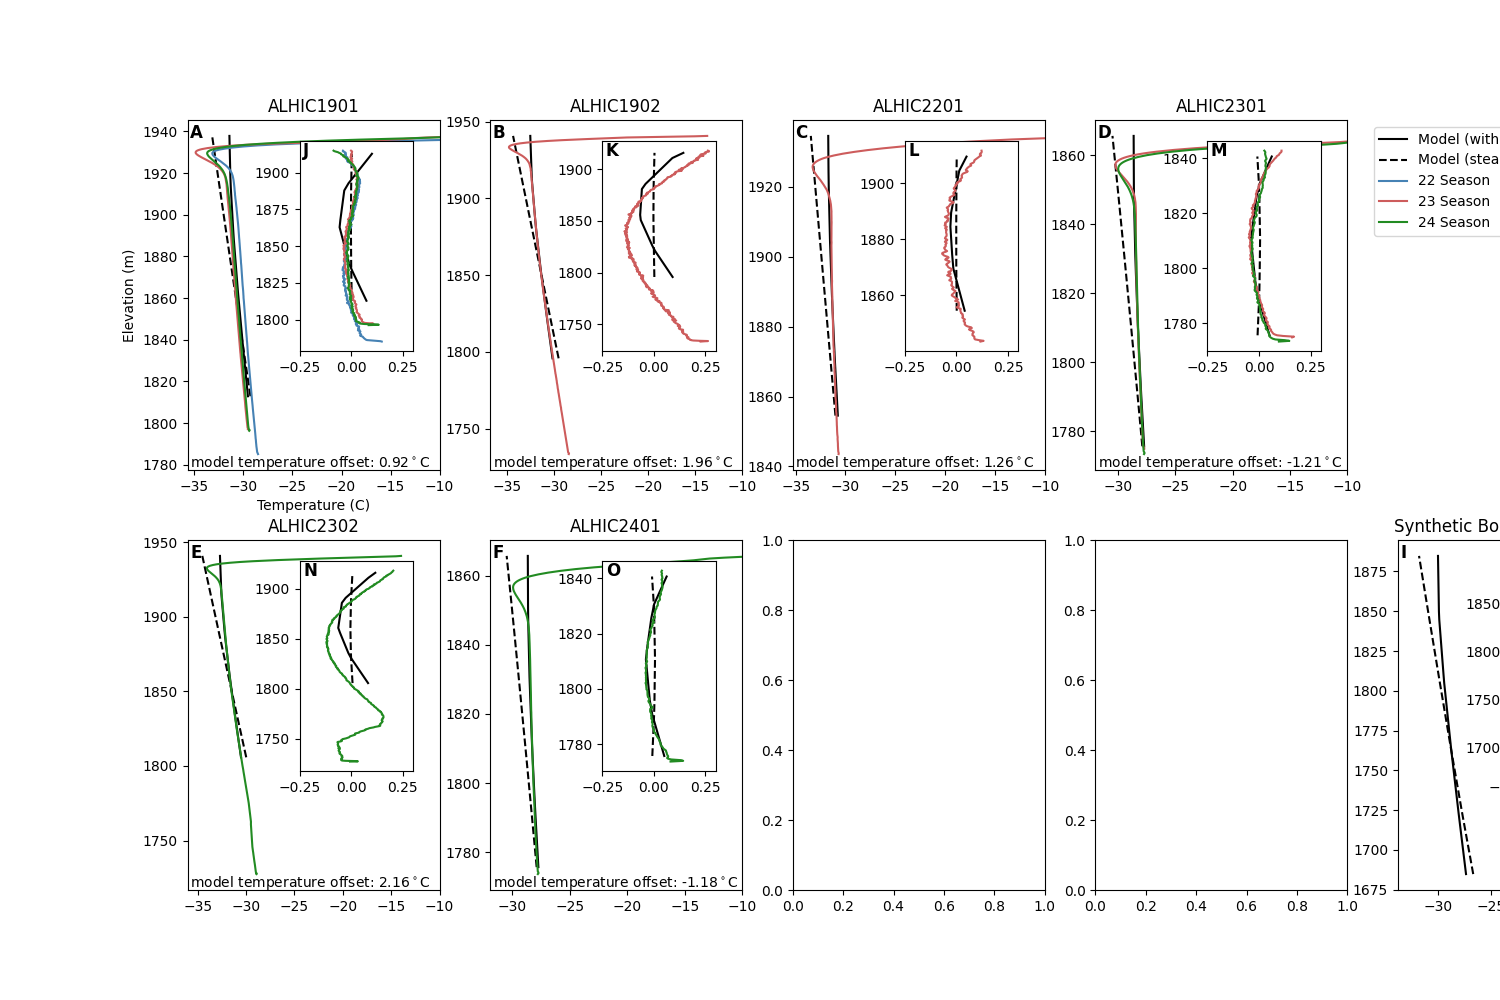

In [119]:
fig,axes = plt.subplots(2, int(((len(temp_dict_climate)+1) /2)+.5), figsize=[15,10])
fig.delaxes(axes[0,-1])

plot_labels = string.ascii_uppercase[:9]
subplot_labels = string.ascii_uppercase[9:18]

temperature_residuals_with_offset = []

### Calculate the offset between the model and the observations ###
for plot_num, (name, ax) in enumerate(zip(temp_dict_climate, fig.axes[:-1])):

    if name == 'PICO2201' or name == 'ALHIC1502':
        continue

    try:
        model_zs = temp_dict_climate[name][1][:,2]
        model_temps_clim = temp_dict_climate[name][0]
        model_temps__no_clim = temp_dict_no_climate[name][0]
        z_offset = model_zs[-1] - core_surface_z[name]

        model_temp_offset_mean = np.mean(borehole_offset_dict[name])

        ax.plot(model_temps_clim - model_temp_offset_mean, model_zs - z_offset, c='black',label='Model (with climate)')
        ax.plot(model_temps__no_clim - model_temp_offset_mean, model_zs - z_offset, c='black', label='Model (steady state)', ls = '--')

        axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
        axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0][:-5]), temp_dict_climate[name][1][:,2][:-5]-z_offset, c='black')
        axinses.plot(scipy.signal.detrend(temp_dict_no_climate[name][0][:-5]), temp_dict_no_climate[name][1][:,2][:-5]-z_offset, ls = '--',c='black')


        ax.annotate('model temperature offset: {:.2f}$^\circ$C'.format(model_temp_offset_mean), xy=(0.01, 0.01), xycoords='axes fraction')
        
    except:
        model_zs = temp_dict_climate[name][1][:,2]
        model_temps_clim = temp_dict_climate[name][0]
        model_temps__no_clim = temp_dict_no_climate[name][0]

        ax.plot(temp_dict_climate[name][0], temp_dict_climate[name][1][:,2], c='black', label='Model')
        ax.plot(temp_dict_no_climate[name][0], temp_dict_no_climate[name][1][:,2], c='black', label='Model (steady state)', ls = '--')

        axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
        axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0][:-5]), temp_dict_climate[name][1][:,2][:-5], c='black')
        axinses.plot(scipy.signal.detrend(temp_dict_no_climate[name][0][:-5]), temp_dict_no_climate[name][1][:,2][:-5], ls = '--',c='black')


        min_temp = temp_dict_no_climate[name][0].min()
        ax.set_xlim([min_temp - 2, -10])

    ax.set_title(name)

    ax.annotate(plot_labels[plot_num], (0.01,0.95), xycoords='axes fraction', fontsize=12, weight='bold')
    axinses.annotate(subplot_labels[plot_num], (0.03,0.93), xycoords='axes fraction', fontsize=12, weight='bold')

    axinses.set_xlim([-0.25,0.3])

    for i in avg_temps:
        if i.startswith(name):
            if i[-2:] == '22':
                color = 'steelblue'
            elif i[-2:] == '23':
                color = 'indianred'
            elif i[-2:] == '24':
                color = 'forestgreen'
            ax.plot(avg_temps[i][2], avg_temps[i][0], label=i[-2:]+' Season',c=color)
            axinses.plot(residual_temps[i][2], residual_temps[i][0], label=i[-2:]+' Season',c=color)

            min_temp = avg_temps[i][2].min()
            ax.set_xlim([min_temp - 2, -10])
    if name == 'ALHIC1901':
        leg = ax.legend( loc = 'upper right')

fig.axes[0].set_ylabel('Elevation (m)')
fig.axes[0].set_xlabel('Temperature (C)')



### Plot the synthetic borehole temperature profile ###

temp_fast_temps = []
temp_fast_temps_clim = []
temp_fast_depths = []
for z_bore in depth_values:
    try:
        temp_fast = T_init.at(510000, -1.3559e6, z_bore)
        temp_fast_clim = Ts[-1].at(510000, -1.3559e6, z_bore)
        temp_fast_temps.append(temp_fast)
        temp_fast_temps_clim.append(temp_fast_clim)
        temp_fast_depths.append(z_bore)
    except:
        continue

axes[1,-1].plot(temp_fast_temps, temp_fast_depths, c='black', ls='--')
axes[1,-1].plot(temp_fast_temps_clim, temp_fast_depths, c='black')

min_temp = np.array(temp_fast_temps).min()
axes[1,-1].set_xlim([min_temp - 2, -10])
axinses = inset_axes(axes[1,-1], width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=axes[1,-1].transAxes, borderpad=1)

axinses.plot(scipy.signal.detrend(temp_fast_temps), temp_fast_depths, c='black', ls='--')
axinses.plot(scipy.signal.detrend(temp_fast_temps_clim), temp_fast_depths, c='black')

axes[1,-1].set_title('Synthetic Borehole in Fast Flow')
axes[1,-1].annotate(plot_labels[-1], (0.01,0.95), xycoords='axes fraction', fontsize=12, weight='bold')
axinses.annotate(subplot_labels[-1], (0.03,0.93), xycoords='axes fraction', fontsize=12, weight='bold')


axinses.set_xlim([-0.25,0.3])

# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(axes[1,-1].transAxes.inverted()) 

# Change to location of the legend. 
xOffset = 4.5
bb.x0 += xOffset
bb.x1 += xOffset
leg.set_bbox_to_anchor(bb, transform = axes[1,-1].transAxes)

plt.tight_layout()

plt.subplots_adjust(right=1.1)

plt.show()



# plt.savefig('Figures/fig2_updated_80m_v3_enhance.eps', dpi=300, bbox_inches='tight', format='eps', transparent=True)
# plt.savefig('Figures/fig2_updated_80m_v3_enhance.png', dpi=300, bbox_inches='tight', format='png', transparent=False)
# plt.savefig('Figures/fig2_updated_80m_v3_enhance.pdf', dpi=300, bbox_inches='tight', format='pdf', transparent=False)

In [120]:
mean_residual_with_offset_applied = np.mean(np.array([x for xs in list(borehole_residual_offset_dict.values()) for x in xs]))
print(mean_residual_with_offset_applied)

0.0473478425948233


In [25]:
name

'PICO2201'

#### Temperatures from a fast flow region

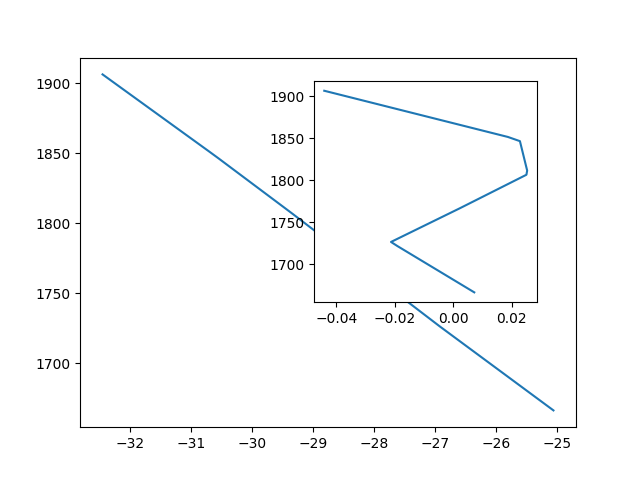

In [16]:
temp_fast_temps = []
temp_fast_depths = []
for z_bore in depth_values:
    try:
        temp_fast = Ts[0].at(510000, -1.3559e6, z_bore)
        temp_fast_temps.append(temp_fast)
        temp_fast_depths.append(z_bore)
    except:
        continue

fig,ax = plt.subplots()

ax.plot(temp_fast_temps, temp_fast_depths)

axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)

axinses.plot(scipy.signal.detrend(temp_fast_temps), temp_fast_depths)

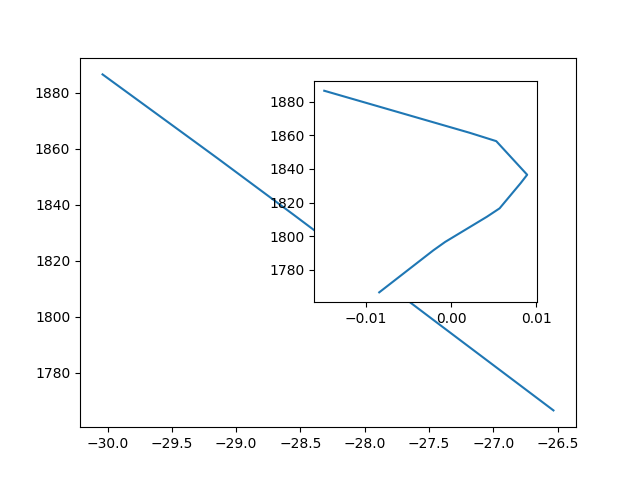

In [223]:
temp_fast_temps = []
temp_fast_depths = []
for z_bore in depth_values:
    try:
        temp_fast = Ts[0].at(508000, -1.3525e6, z_bore)
        temp_fast_temps.append(temp_fast)
        temp_fast_depths.append(z_bore)
    except:
        continue



fig,ax = plt.subplots()

ax.plot(temp_fast_temps, temp_fast_depths)

axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)

axinses.plot(scipy.signal.detrend(temp_fast_temps), temp_fast_depths)

# Notes 10/28

- Two rows of plots
    - top plots would be climate history with advection
    - bottom row would be no climate

- Include the fake borehole in line with the other

- Make an updated map view of the advection importance

# what if we made only a conduction problem (took out advection) then subtract from the real profile?
the more advective boreholes should diverge more, right?

# 1. Load the necessary data

In [121]:
V = firedrake.FunctionSpace(mesh_fine, "CG", 1)

T = firedrake.Function(V)

chk = DumbCheckpoint("Saved_Models/fine_mesh_temperature_80.0m_updated_viscosity_e1.97", mode=FILE_READ)
chk.load(T, name="fine_mesh_temp")

T_init = T.copy(deepcopy=True)

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


In [122]:
from ufl import Measure
dx = ufl.Measure("dx", domain=mesh_fine)


ϕ = firedrake.TestFunction(V)

geo_flux = 0.04 # W/m^2 
k = Constant(2.22)  # W / m C

geothermal_flux = -geo_flux*ϕ  * ds_b
F_diffusion = k*inner(grad(T), grad(ϕ)) * dx

F = ρ * c * Dt(T) * ϕ * dx + F_diffusion + geothermal_flux

In [123]:
mag = 2

T_mean = Constant(-33) #average temp (C)
T_Mean = -33 #average temp (C)

temperature_expr = T_mean - (z_src - 2000)*.01

surface_temp_bc = firedrake.DirichletBC(V, temperature_expr, 'top')

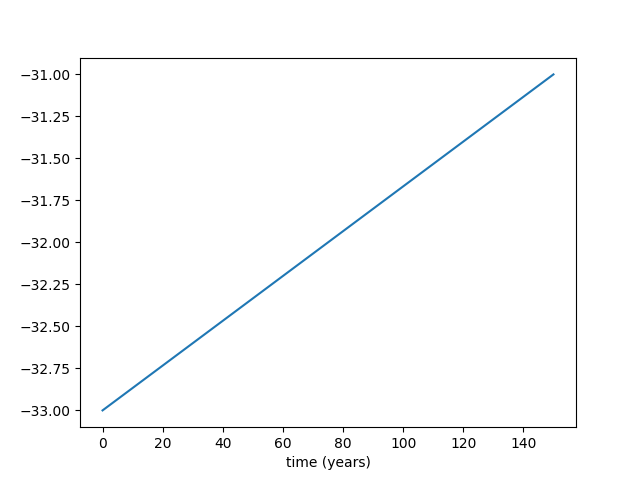

In [124]:
δT = 25.0
θ = 1 * π / 2
year = spy
years = 150
final_time = years * spy # years modeling * spy


freq = 1 # 1 for annual cycle
num_steps = int(final_time / float(δt))

# def surface_temperature(t):
#     return T_Mean + δT * np.sin(2 * π *freq* t / year + θ) + (t/final_time)*1

def surface_temperature(t):
    return T_Mean + (t/final_time)*mag

ts = np.linspace(0.0, final_time, num_steps + 1)

surface_temps = surface_temperature(ts)

fig, ax = plt.subplots()

ax.set_xlabel("time (years)")
#ax.set_ylabel("temperature (${}^\circ$C)")
ax.plot(ts / spy, surface_temps);

In [125]:


# surface_temps = np.array([-30.5 , -30.5, -30.5, -30.9, -31, -31.5 , -31.8, -32, -32.2, -32.4, -32. ])

# fig, ax = plt.subplots()

# ax.set_xlabel("time (years)")
# #ax.set_ylabel("temperature (${}^\circ$C)")
# ax.plot(ts / spy, surface_temps);

In [126]:
method = irksome.BackwardEuler()
temperature_solver = irksome.TimeStepper(F, method, Constant(0.0), δt, T, bcs=surface_temp_bc)

In [127]:
import tqdm
final_time = years* spy 
num_steps = int(final_time / float(δt))
Ts = [T.copy(deepcopy=True)]

for step in tqdm.trange(num_steps):
    t = ts[step]
    T_mean.assign(surface_temperature(t))

    temperature_solver.advance()


    Ts.append(T.copy(deepcopy=True))


100%|██████████| 15/15 [00:09<00:00,  1.53it/s]


In [128]:
z_vals = mesh_fine.coordinates.dat.data_ro[:,2]
depth_values = np.arange(z_vals.min(), z_vals.max(), 5)

temp_dict_climate_no_adv = {}
temp_dict_no_climate_no_adv = {}

for x_bore, y_bore, name_bore in zip(transformed_x, transformed_y, borehole_locations['Core']):
    temp_coords = []
    temp_clim_vals = []
    temp_no_clim_vals = []
    for z_bore in depth_values:
        try:
            temp_clim = Ts[-1].at(x_bore, y_bore, z_bore)
            temp_no_clim = T_init.at(x_bore, y_bore, z_bore)
            temp_coords.append([x_bore, y_bore, z_bore])
            temp_clim_vals.append(temp_clim)
            temp_no_clim_vals.append(temp_no_clim)


        except:
            continue
    if len(temp_clim_vals) > 0:
        temp_dict_climate_no_adv[name_bore] = [np.array(temp_clim_vals), np.array(temp_coords)]
        temp_dict_no_climate_no_adv[name_bore] = [np.array(temp_no_clim_vals), np.array(temp_coords)]


In [137]:
# fig,axes = plt.subplots(2, int(((len(temp_dict_climate)+1) /2)+.5), figsize=[15,10])
# fig.delaxes(axes[0,-1])

borehole_offset_dict = defaultdict(list)
borehole_residual_offset_dict = defaultdict(list)

temp_residuals_from_only_clim_model = defaultdict(list)


for n,borehole_name_clim in enumerate(temp_dict_climate_no_adv):

    for borehole_name_data in avg_temps:

        if borehole_name_data.startswith(borehole_name_clim):

            model_zs = temp_dict_climate_no_adv[borehole_name_clim][1][:,2]
            model_temps = temp_dict_climate_no_adv[borehole_name_clim][0]

            z_offset = model_zs[-1] - core_surface_z[borehole_name_clim]
            model_zs = model_zs - z_offset


            data_zs = avg_temps[borehole_name_data][0].values
            data_temps = avg_temps[borehole_name_data][2].values


            # print('data z is '+str(data_zs[-1])+' and the model z is '+str(model_zs[0]))
            if data_zs[-1] < model_zs[0]:
                f = scipy.interpolate.interp1d(data_zs, data_temps)
                data_temps_model_zs = f(model_zs)

                # ax.plot(model_temps[:-5],model_zs[:-5], label='model temps')
                # ax.plot(data_temps_model_zs[:-5], model_zs[:-5], label='data temps')

                mean_temp_offsets = np.mean(model_temps[:-5] - data_temps_model_zs[:-5])

                residuals_with_offset = np.mean(np.abs((model_temps[:-5] - mean_temp_offsets) - data_temps_model_zs[:-5]))

                # ax.plot(model_temps[:-5] - mean_temp_offsets, model_zs[:-5],  label='model temp with offset')



                # ax.set_title(borehole_name_clim)
                # print('mean offset for ' + borehole_name_clim+ ' is ' + str(mean_temp_offsets))
                # print('mean model with offset and data diff is ' + str( np.mean(np.abs((model_temps[:-5] - mean_temp_offsets) - data_temps_model_zs[:-5]))))

                temp_residuals_from_only_clim_model[borehole_name_clim].append((model_temps[:-5] - mean_temp_offsets) - data_temps_model_zs[:-5])


            else:
                print('note the case')

            borehole_offset_dict[borehole_name_clim].append(mean_temp_offsets)
            borehole_residual_offset_dict[borehole_name_clim].append(residuals_with_offset)
    model_temp_offset_mean = np.mean(borehole_offset_dict[name])


In [138]:
temp_dict_climate_no_adv

{'ALHIC1901': [array([-28.71399757, -28.82108174, -28.92816592, -29.03525009,
         -29.14233427, -29.24770349, -29.34490468, -29.44210588,
         -29.53930707, -29.63650826, -29.73370945, -29.81482462,
         -29.8947393 , -29.97465399, -30.05456867, -30.13448336,
         -30.19608395, -30.24936315, -30.30264235, -30.35592155,
         -30.40920075, -30.44578236, -30.46150604, -30.47722971,
         -30.49295339, -30.50867707]),
  array([[  510423.76218009, -1354816.23040865,     1809.7978852 ],
         [  510423.76218009, -1354816.23040865,     1814.7978852 ],
         [  510423.76218009, -1354816.23040865,     1819.7978852 ],
         [  510423.76218009, -1354816.23040865,     1824.7978852 ],
         [  510423.76218009, -1354816.23040865,     1829.7978852 ],
         [  510423.76218009, -1354816.23040865,     1834.7978852 ],
         [  510423.76218009, -1354816.23040865,     1839.7978852 ],
         [  510423.76218009, -1354816.23040865,     1844.7978852 ],
         [  51

In [139]:
temp_residuals_from_only_clim_model

defaultdict(list,
            {'ALHIC1901': [array([ 0.09007664,  0.07915971,  0.06435112,  0.04617771,  0.02934025,
                      0.00790278, -0.00468948, -0.0174891 , -0.02914961, -0.05091773,
                     -0.06972936, -0.07268766, -0.07106509, -0.0756422 , -0.07692565,
                     -0.07577603, -0.0564698 , -0.01160333,  0.04009385,  0.10558237,
                      0.14946065]),
              array([ 0.03945336,  0.03336656,  0.02724039,  0.01954663,  0.00756474,
                     -0.00497017, -0.0115779 , -0.01257457, -0.02451198, -0.03970694,
                     -0.04921391, -0.0533235 , -0.05349146, -0.05394355, -0.0526627 ,
                     -0.04878342, -0.02874214,  0.0073084 ,  0.0565779 ,  0.10227019,
                      0.14017406]),
              array([ 0.07046811,  0.0545447 ,  0.04238506,  0.02472412,  0.00669119,
                     -0.00767477, -0.01855603, -0.03114709, -0.03528988, -0.04871253,
                     -0.06445342, -0.

<>:60: SyntaxWarning: invalid escape sequence '\c'
<>:60: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1236320/164930708.py:60: SyntaxWarning: invalid escape sequence '\c'
  ax.annotate('model temperature offset: {:.2f}$^\circ$C'.format(model_temp_offset_mean), xy=(0.01, 0.01), xycoords='axes fraction', fontsize=9)
/tmp/ipykernel_1236320/164930708.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=[25,8], layout="constrained")
/tmp/ipykernel_1236320/164930708.py:117: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(right=1.2)
/tmp/ipykernel_1236320/164930708.py:153: Us

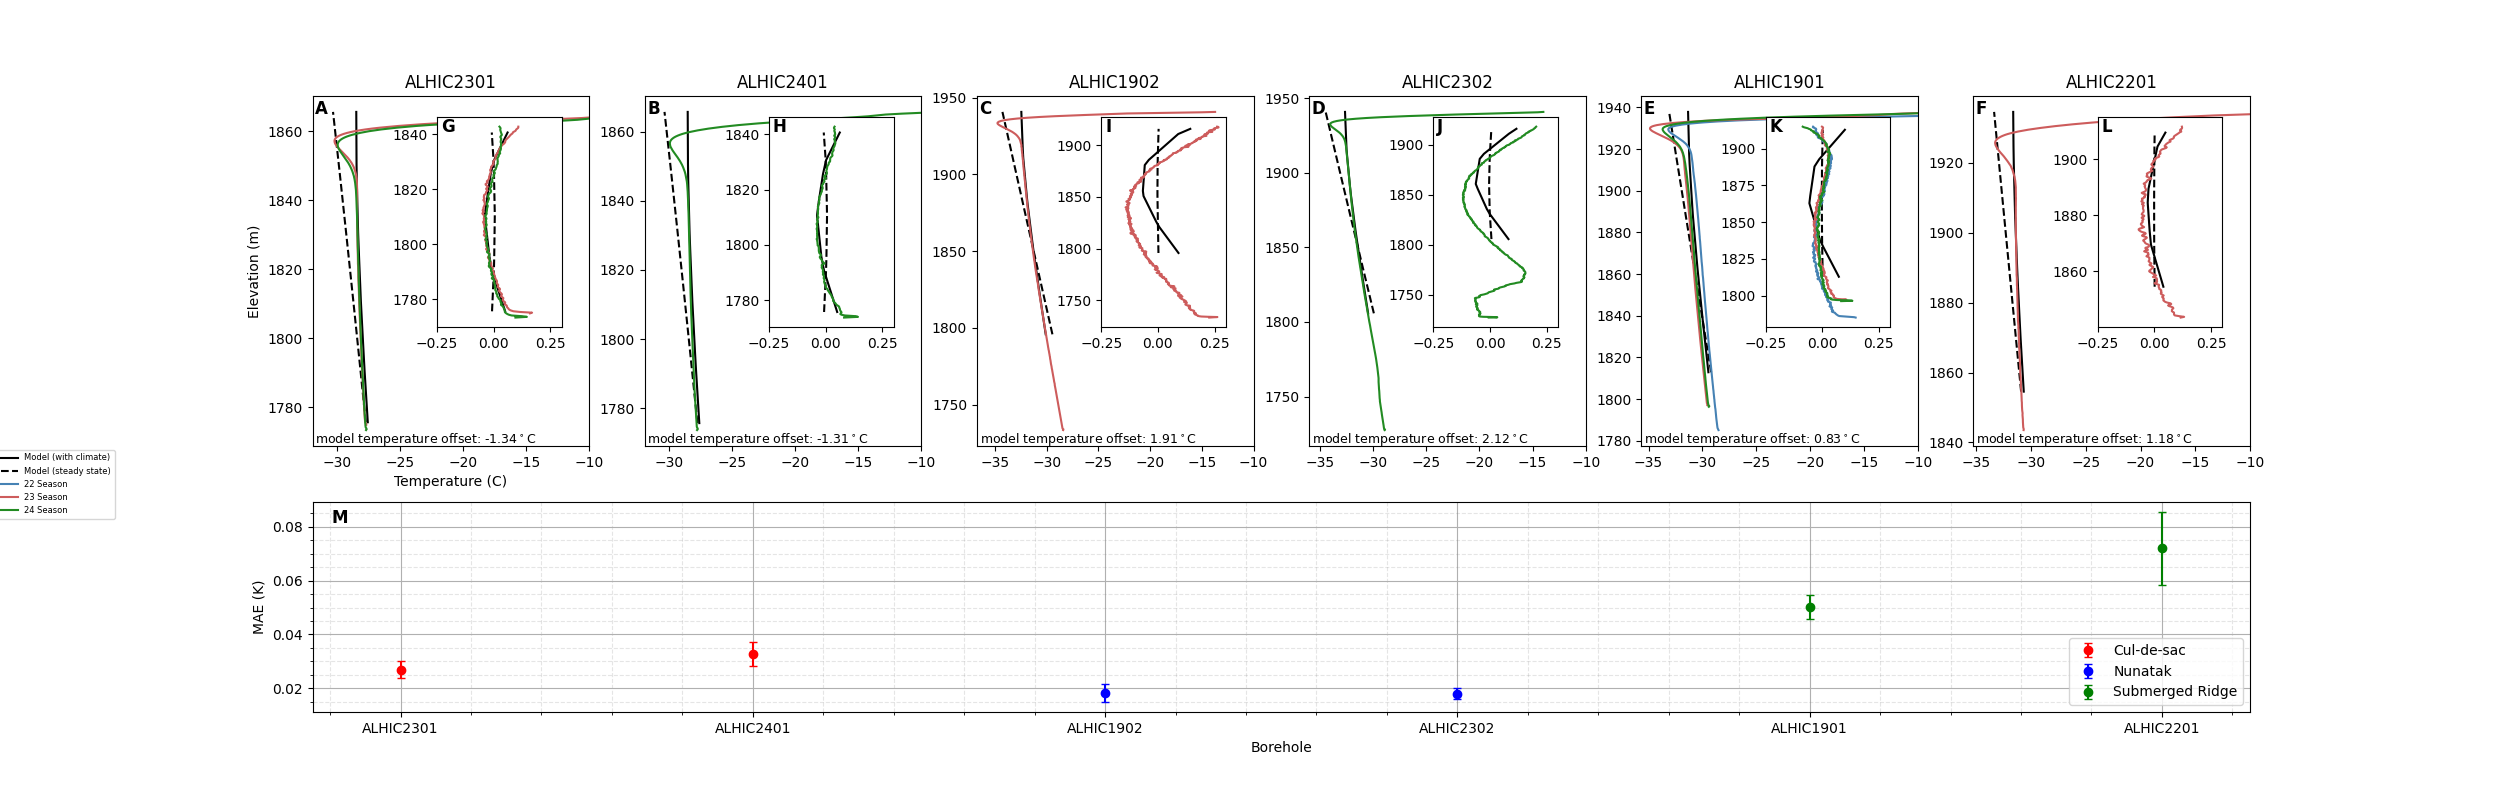

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [143]:
fig = plt.figure(figsize=[25,8], layout="constrained")
gs = GridSpec(2, 6, figure=fig, height_ratios=[5,3])

plot_labels = string.ascii_uppercase[:6]
subplot_labels = string.ascii_uppercase[6:12]

temperature_residuals_with_offset = []

### Calculate the offset between the model and the observations ###
for plot_num, name in enumerate(temp_dict_climate):
    if name == 'ALHIC2301':
        plot_num = 0

    if name == 'ALHIC2401':
        plot_num = 1

    if name == 'ALHIC1902':
        plot_num = 2

    if name == 'ALHIC2302':
        plot_num = 3

    if name == 'ALHIC1901':
        plot_num = 4

    if name == 'ALHIC2201':
        plot_num = 5




    if name == 'PICO2201' or name == 'ALHIC1502':
        continue

    ax = fig.add_subplot(gs[0, plot_num])
    if plot_num == 0:
        ax.set_ylabel('Elevation (m)')
        ax.set_xlabel('Temperature (C)')


    axinses = inset_axes(ax, width = "100%", height = "100%", loc='lower right', bbox_to_anchor=(.5, .30, .45, .60), bbox_transform=ax.transAxes, borderpad=1)
    ax.annotate(plot_labels[plot_num], (0.01,0.95), xycoords='axes fraction', fontsize=12, weight='bold')
    axinses.annotate(subplot_labels[plot_num], (0.03,0.93), xycoords='axes fraction', fontsize=12, weight='bold')

    model_zs = temp_dict_climate[name][1][:,2]
    model_temps_clim = temp_dict_climate[name][0]
    model_temps__no_clim = temp_dict_no_climate[name][0]
    z_offset = model_zs[-1] - core_surface_z[name]

    model_temp_offset_mean = np.mean(borehole_offset_dict[name])

    ax.plot(model_temps_clim - model_temp_offset_mean, model_zs - z_offset, c='black',label='Model (with climate)')
    ax.plot(model_temps__no_clim - model_temp_offset_mean, model_zs - z_offset, c='black', label='Model (steady state)', ls = '--')


    axinses.plot(scipy.signal.detrend(temp_dict_climate[name][0][:-5]), temp_dict_climate[name][1][:,2][:-5]-z_offset, c='black')
    axinses.plot(scipy.signal.detrend(temp_dict_no_climate[name][0][:-5]), temp_dict_no_climate[name][1][:,2][:-5]-z_offset, ls = '--',c='black')


    ax.annotate('model temperature offset: {:.2f}$^\circ$C'.format(model_temp_offset_mean), xy=(0.01, 0.01), xycoords='axes fraction', fontsize=9)

    ax.set_xlim([min_temp - 2, -10])

    ax.set_title(name)

    axinses.set_xlim([-0.25,0.3])

    for i in avg_temps:
        if i.startswith(name):
            if i[-2:] == '22':
                color = 'steelblue'
            elif i[-2:] == '23':
                color = 'indianred'
            elif i[-2:] == '24':
                color = 'forestgreen'
            ax.plot(avg_temps[i][2], avg_temps[i][0], label=i[-2:]+' Season',c=color)
            axinses.plot(residual_temps[i][2], residual_temps[i][0], label=i[-2:]+' Season',c=color)

            min_temp = avg_temps[i][2].min()
            ax.set_xlim([min_temp - 2, -10])
    if name == 'ALHIC1901':
        leg = ax.legend( loc = 'upper right', fontsize=6)
        ax.set_zorder(99)
        axinses.set_zorder(100)



### Plot the synthetic borehole temperature profile ###

temp_fast_temps = []
temp_fast_temps_clim = []
temp_fast_depths = []
for z_bore in depth_values:
    try:
        temp_fast = T_init.at(510000, -1.3559e6, z_bore)
        temp_fast_clim = Ts[-1].at(510000, -1.3559e6, z_bore)
        temp_fast_temps.append(temp_fast)
        temp_fast_temps_clim.append(temp_fast_clim)
        temp_fast_depths.append(z_bore)
    except:
        continue



# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(fig.axes[0].transAxes.inverted()) 

# Change to location of the legend. 
xOffset = -6.5
bb.x0 += xOffset
bb.x1 += xOffset
bb.y0 += -1
bb.y1 += -1

leg.set_bbox_to_anchor(bb, transform = fig.axes[0].transAxes)

plt.subplots_adjust(right=1.2)

rmse_of_model_residuals = {}

for i in temp_residuals_from_only_clim_model:
    residuals = np.array(temp_residuals_from_only_clim_model[i]).T.flatten()

    rmse = np.sqrt(np.sum((residuals**2) / len(residuals)))

    rmse_of_model_residuals[i] = [np.mean(np.abs(residuals)), np.std(np.abs(residuals))/np.sqrt(len(residuals))]


ax = fig.add_subplot(gs[1, :])

key_order = ('ALHIC2301', 'ALHIC2401', 'ALHIC1902', 'ALHIC2302', 'ALHIC1901', 'ALHIC2201')
rmse_of_model_residuals = OrderedDict((k, rmse_of_model_residuals[k]) for k in key_order)



for i,clr, lbl in zip([[0,2], [2,4], [4,6]], ['red','blue','green'], ['Cul-de-sac','Nunatak','Submerged Ridge']):
    new_mae_dict = dict(list(rmse_of_model_residuals.items())[i[0]:i[1]])
    ax.errorbar(new_mae_dict.keys(), 
                np.array(list(new_mae_dict.values()))[:,0], 
                yerr=np.array(list(new_mae_dict.values()))[:,1], 
                fmt='o',
                capsize=3, 
                color=clr,
                label=lbl)
ax.annotate('M', (0.01,0.90), xycoords='axes fraction', fontsize=12, weight='bold')
ax.set_xlabel('Borehole')
ax.set_ylabel('MAE (K)')

ax.grid(which='major')
ax.minorticks_on()
ax.grid(which='minor', color='grey', alpha=0.2, ls='--')
ax.legend()
plt.tight_layout()

plt.show()



plt.savefig('Figures/fig2_updated_80m_v3_enhance_mae.eps', dpi=300, format='eps', transparent=True)
plt.savefig('Figures/fig2_updated_80m_v3_enhance_mae.png', dpi=300, format='png', transparent=False)
plt.savefig('Figures/fig2_updated_80m_v3_enhance_mae.pdf', dpi=300, format='pdf', transparent=False)

In [77]:
# fig,ax = plt.subplots()

# for name in temp_dict_climate:
#     model_temps = temp_dict_climate[name][0]
#     model_zs = temp_dict_climate[name][1][:,-1]

#     for i in avg_temps:
#             if i.startswith(name):
#                 if i[-2:] == '22':
#                     color = 'steelblue'
#                 elif i[-2:] == '23':
#                     color = 'indianred'
#                 elif i[-2:] == '24':
#                     color = 'forestgreen'
#                 ax.plot(avg_temps[i][0], avg_temps[i][2], label=i[-2:]+' Season',c=color)

#     ax.plot(model_zs, model_temps, label=i)
# plt.legend()


In [96]:
temp_residuals_from_only_clim_model

defaultdict(list,
            {'ALHIC1901': [array([ 0.09007664,  0.07915971,  0.06435112,  0.04617771,  0.02934025,
                      0.00790278, -0.00468948, -0.0174891 , -0.02914961, -0.05091773,
                     -0.06972936, -0.07268766, -0.07106509, -0.0756422 , -0.07692565,
                     -0.07577603, -0.0564698 , -0.01160333,  0.04009385,  0.10558237,
                      0.14946065]),
              array([ 0.03945336,  0.03336656,  0.02724039,  0.01954663,  0.00756474,
                     -0.00497017, -0.0115779 , -0.01257457, -0.02451198, -0.03970694,
                     -0.04921391, -0.0533235 , -0.05349146, -0.05394355, -0.0526627 ,
                     -0.04878342, -0.02874214,  0.0073084 ,  0.0565779 ,  0.10227019,
                      0.14017406]),
              array([ 0.07046811,  0.0545447 ,  0.04238506,  0.02472412,  0.00669119,
                     -0.00767477, -0.01855603, -0.03114709, -0.03528988, -0.04871253,
                     -0.06445342, -0.

In [ ]:
fig,ax = plt.subplots()

ax.plot

In [126]:
rmse_of_model_residuals = {}

for i in temp_residuals_from_only_clim_model:
    residuals = np.array(temp_residuals_from_only_clim_model[i]).T.flatten()

    rmse = np.sqrt(np.sum((residuals**2) / len(residuals)))

    rmse_of_model_residuals[i] = [np.mean(np.abs(residuals)), np.std(np.abs(residuals))/np.sqrt(len(residuals))]


In [127]:
np.array(list(rmse_of_model_residuals.values()))

array([[0.05031858, 0.00447915],
       [0.01819919, 0.00344761],
       [0.07204891, 0.01362977],
       [0.02692929, 0.00310708],
       [0.0180537 , 0.00189084],
       [0.03275495, 0.00431789]])

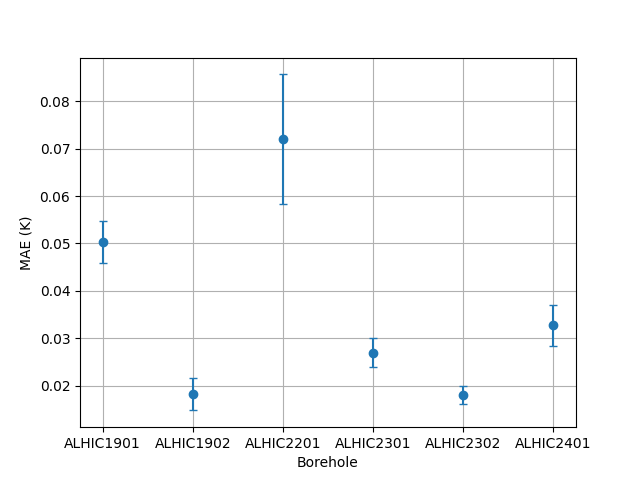

In [143]:
fig,ax = plt.subplots()

ax.errorbar(rmse_of_model_residuals.keys(), 
            np.array(list(rmse_of_model_residuals.values()))[:,0], 
            yerr=np.array(list(rmse_of_model_residuals.values()))[:,1], 
            fmt='o',
            capsize=3)

ax.set_xlabel('Borehole')
ax.set_ylabel('MAE (K)')
ax.grid()

plt.savefig('Figures/fig2_borehole_temp_fig_replacement.png', dpi=600, bbox_inches='tight', format='png', transparent=False)

TypeError: 'dict_values' object is not subscriptable

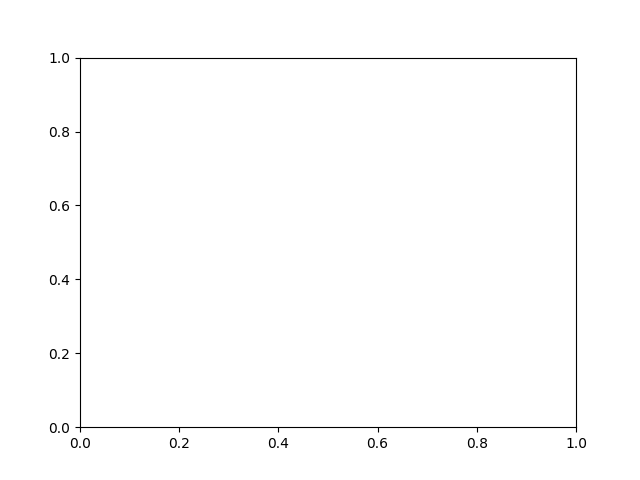

In [122]:
fig,ax = plt.subplots()

ax.scatter(rmse_of_model_residuals.keys(), rmse_of_model_residuals.values()[0])

In [117]:
rmse_of_model_residuals

{'ALHIC1901': np.float64(0.06161097846606164),
 'ALHIC1902': np.float64(0.02506713059369145),
 'ALHIC2201': np.float64(0.08614112914063475),
 'ALHIC2301': np.float64(0.03155149286227878),
 'ALHIC2302': np.float64(0.02020315223803789),
 'ALHIC2401': np.float64(0.03652266419122784)}

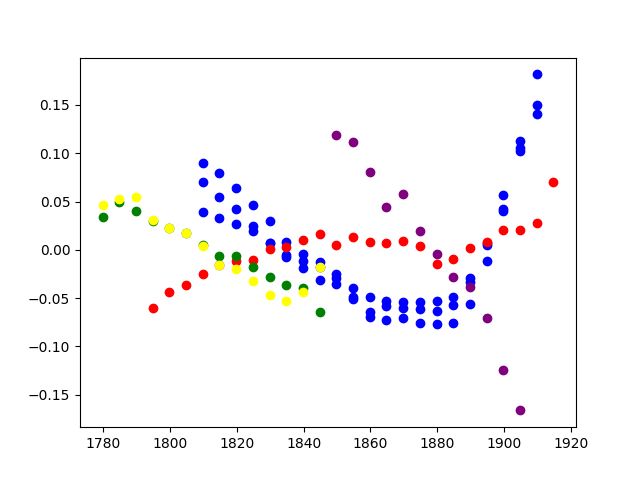

In [101]:
fig,ax = plt.subplots()

ax.scatter(temp_dict_climate['ALHIC1901'][1][:,2][:-5], np.array(temp_residuals_from_only_clim_model['ALHIC1901']).T[:,0], c='blue')
ax.scatter(temp_dict_climate['ALHIC1901'][1][:,2][:-5], np.array(temp_residuals_from_only_clim_model['ALHIC1901']).T[:,1], c='blue')
ax.scatter(temp_dict_climate['ALHIC1901'][1][:,2][:-5], np.array(temp_residuals_from_only_clim_model['ALHIC1901']).T[:,2], c='blue')

ax.scatter(temp_dict_climate['ALHIC2201'][1][:,2][:-5], np.array(temp_residuals_from_only_clim_model['ALHIC2201']).T[:,0], c='purple')

ax.scatter(temp_dict_climate['ALHIC1902'][1][:,2][:-5], np.array(temp_residuals_from_only_clim_model['ALHIC1902']).T[:,0], c='red')

ax.scatter(temp_dict_climate['ALHIC2301'][1][:,2][:-5], np.array(temp_residuals_from_only_clim_model['ALHIC2301']).T[:,0], c='green')

ax.scatter(temp_dict_climate['ALHIC2401'][1][:,2][:-5], np.array(temp_residuals_from_only_clim_model['ALHIC2401']).T[:,0], c='yellow')
# ax.scatter(temp_dict_climate['ALHIC1901'][1][:,2][:-5], np.array(temp_residuals_from_only_clim_model['ALHIC1901']).T[:,1], c='blue')
# ax.scatter(temp_dict_climate['ALHIC1901'][1][:,2][:-5], np.array(temp_residuals_from_only_clim_model['ALHIC1901']).T[:,2], c='blue')


In [79]:
temp_residuals_from_only_clim_model.keys()

dict_keys(['ALHIC1901', 'ALHIC1902', 'ALHIC2201', 'ALHIC2301', 'ALHIC2302', 'ALHIC2401'])

In [83]:
np.array(temp_residuals_from_only_clim_model['ALHIC1901'])

array([[ 0.09007664,  0.07915971,  0.06435112,  0.04617771,  0.02934025,
         0.00790278, -0.00468948, -0.0174891 , -0.02914961, -0.05091773,
        -0.06972936, -0.07268766, -0.07106509, -0.0756422 , -0.07692565,
        -0.07577603, -0.0564698 , -0.01160333,  0.04009385,  0.10558237,
         0.14946065],
       [ 0.03945336,  0.03336656,  0.02724039,  0.01954663,  0.00756474,
        -0.00497017, -0.0115779 , -0.01257457, -0.02451198, -0.03970694,
        -0.04921391, -0.0533235 , -0.05349146, -0.05394355, -0.0526627 ,
        -0.04878342, -0.02874214,  0.0073084 ,  0.0565779 ,  0.10227019,
         0.14017406],
       [ 0.07046811,  0.0545447 ,  0.04238506,  0.02472412,  0.00669119,
        -0.00767477, -0.01855603, -0.03114709, -0.03528988, -0.04871253,
        -0.06445342, -0.05809385, -0.06064338, -0.06093897, -0.06301966,
        -0.05751702, -0.03334151,  0.00454923,  0.04217069,  0.11224295,
         0.18161204]])

In [45]:
model_temps

array([-29.07928223, -29.16240814, -29.24553405, -29.32865995,
       -29.40222723, -29.46907384, -29.53592044, -29.60276705,
       -29.65209119, -29.69932738, -29.74656357, -29.7889316 ,
       -29.81181399, -29.83469638, -29.85757877, -29.86501223,
       -29.85737865, -29.84974507, -29.84211149])

In [47]:
borehole_offset_dict

defaultdict(list,
            {'ALHIC1901': [np.float64(0.3540279874262067),
              np.float64(1.1415783521477736),
              np.float64(0.9998319705067531)],
             'PICO2201': [],
             'ALHIC1902': [np.float64(1.9146817254674153)],
             'ALHIC2201': [np.float64(1.178953498772265)],
             'ALHIC2301': [np.float64(-1.3273312421685914),
              np.float64(-1.337412105896134)],
             'ALHIC2302': [np.float64(2.1179386691372297)],
             'ALHIC2401': [np.float64(-1.306416777493406)]})

In [46]:
data_temps

array([ -8.98525  ,  -9.9979375, -11.5716875, -12.8403125, -13.529375 ,
       -14.2378125, -15.245625 , -16.3918125, -17.515875 , -18.632625 ,
       -19.7801875, -20.9048125, -21.9443125, -22.8863125, -23.7366875,
       -24.5011875, -25.1899375, -25.813375 , -26.3766875, -26.8825   ,
       -27.333375 , -27.736375 , -28.094125 , -28.412    , -28.6928125,
       -28.936625 , -29.144625 , -29.3236875, -29.4768125, -29.6024375,
       -29.703875 , -29.786125 , -29.8498125, -29.89525  , -29.923375 ,
       -29.9388125, -29.9443125, -29.9389375, -29.9250625, -29.90675  ,
       -29.879125 , -29.8411875, -29.8      , -29.7616875, -29.7214375,
       -29.674625 , -29.6245   , -29.5741875, -29.522375 , -29.47125  ,
       -29.422375 , -29.3730625, -29.3228125, -29.275625 , -29.2305625,
       -29.1854375, -29.1420625, -29.101875 , -29.06175  , -29.02375  ,
       -28.988    , -28.9549375, -28.9235   , -28.8928125, -28.8655625,
       -28.8400625, -28.8134375, -28.7875625, -28.76375  , -28.7

In [ ]:

for n,borehole_name_clim in enumerate(temp_dict_climate):
    for borehole_name_data in avg_temps:
        if borehole_name_data.startswith(borehole_name_clim):

            model_zs = temp_dict_climate[borehole_name_clim][1][:,2]
            model_temps = temp_dict_climate[borehole_name_clim][0]

            z_offset = model_zs[-1] - core_surface_z[borehole_name_clim]
            model_zs = model_zs - z_offset


            data_zs = avg_temps[borehole_name_data][0].values
            data_temps = avg_temps[borehole_name_data][2].values

            print(borehole_offset_dict[borehole_name_data[:-3]])


[np.float64(0.3540279874262067), np.float64(1.1415783521477736), np.float64(0.9998319705067531)]
[np.float64(0.3540279874262067), np.float64(1.1415783521477736), np.float64(0.9998319705067531)]
[np.float64(0.3540279874262067), np.float64(1.1415783521477736), np.float64(0.9998319705067531)]
[np.float64(1.9146817254674153)]
[np.float64(1.178953498772265)]
[np.float64(-1.3273312421685914), np.float64(-1.337412105896134)]
[np.float64(-1.3273312421685914), np.float64(-1.337412105896134)]
[np.float64(2.1179386691372297)]
[np.float64(-1.306416777493406)]


In [68]:
borehole_offset_dict

defaultdict(list,
            {'ALHIC1901': [np.float64(0.3540279874262067),
              np.float64(1.1415783521477736),
              np.float64(0.9998319705067531)],
             'PICO2201': [],
             'ALHIC1902': [np.float64(1.9146817254674153)],
             'ALHIC2201': [np.float64(1.178953498772265)],
             'ALHIC2301': [np.float64(-1.3273312421685914),
              np.float64(-1.337412105896134)],
             'ALHIC2302': [np.float64(2.1179386691372297)],
             'ALHIC2401': [np.float64(-1.306416777493406)]})